# Candidate generation для поиска услуг Авито

Для каждого запроса нужно вернуть до 50 ID объявлений. BM25 собирает кандидатов,
а CatBoost выбирает итоговые 50 по тексту и контексту поиска. Всё работает на CPU.

Перед запуском прочитайте [README](README.md). Ячейки идут сверху вниз.
В первой ячейке `rebuild = False` включает просмотр сохранённых отчётов;
`rebuild = True` заново выполняет вычисления по исходным Parquet.

Код этапов разделён на небольшие модули. Например, ячейка
`execute_stage("train", "training.json")` при полном запуске вызывает обучение
из `avito_ranker/model.py`, затем показывает отчёт `results/training.json`.
В режиме просмотра она только показывает уже сохранённый отчёт.

| Где смотреть | Что выполняется |
| --- | --- |
| [prepare.py](avito_ranker/prepare.py) | Разбиение запросов и подготовка корпуса |
| [candidates.py](avito_ranker/candidates.py) | Поиск и объединение кандидатов |
| [features.py](avito_ranker/features.py) | Признаки пары «запрос — объявление» |
| [dataset.py](avito_ranker/dataset.py) | Сбор таблиц признаков и обучающих меток |
| [model.py](avito_ranker/model.py) | Обучение, выбор на dev и оценка |
| [predict.py](avito_ranker/predict.py) | Формирование `results/answer.csv` |

Последняя ячейка сохраняет копию ответа в корне репозитория: `answer.csv`.
Описание метода — в [docs/approach.md](docs/approach.md), результаты и ошибки —
в [docs/results.md](docs/results.md).

## Результат выполненного эксперимента

Сравнение на одинаковом корпусе из 515 895 объявлений:

| Метод | Dev Recall@50 | Holdout Recall@50 |
| --- | ---: | ---: |
| BM25 + RRF | 28.96% | 27.76% |
| RRF с бонусом за локацию | 61.27% | 58.70% |
| CatBoost | 74.10% | 72.45% |

Прирост CatBoost к исходному RRF на holdout: **44.69 п.п.**
Это локальная оценка по известным положительным парам. Закрытый результат Авито неизвестен.
Holdout уже использован для этой оценки; повтор запуска воспроизводит эксперимент, а не создаёт новый независимый тест.

## 1. Окружение

В `ranking.toml` задаются пути к данным и рабочим папкам. Относительные пути считаются от конфигурации. Пакеты устанавливаются по `requirements-notebook.txt`.

In [1]:
import json
from pathlib import Path
import subprocess
import sys

from avito_ranker.config import load_config
from avito_ranker.workflow import run_stage
from avito_ranker.freeze import check_frozen

rebuild = False  # True — заново выполнить поиск, обучение и проверку.
config_path = Path("ranking.toml").resolve()
config = load_config(config_path)

def show_result(name):
    return json.loads((config["results_dir"] / name).read_text("utf-8"))

def execute_stage(stage, result=None):
    if rebuild:
        run_stage(stage, config_path)
    return show_result(result) if result else f"Лог этапа: results/logs/{stage}"

if not rebuild:
    check_frozen(config)
subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"], check=True)
{"rebuild": rebuild, "config": config_path.name, "threads": config["threads"]}

resource module not available on Windows


{'rebuild': False, 'config': 'ranking.toml', 'threads': 2}

## 2. Данные и разбиение

В одной группе остаются перестановки слов и формы с одинаковыми основами. Группы train, dev и holdout не пересекаются. Ранее просмотренные группы могут попасть только в dev. Корпус включает все уникальные объявления и не зависит от положительных меток.

In [2]:
execute_stage("prepare", "split_audit.json")

{'corpus_items': 515895,
 'corpus_rule': 'all unique items; benchmark features take precedence on duplicates',
 'strict_group': 'sorted unique Snowball tokens; punctuation/case/word order ignored',
 'groups_disjoint': True,
 'holdout_previously_seen_groups': 0,
 'query_selection_uses_labels': False,
 'corpus_selection_uses_labels': False,
 'query_counts': {'train': 8000, 'dev': 2000, 'holdout': 2000},
 'all_group_counts': [{'fold': 'dev', 'len': 11217},
  {'fold': 'holdout', 'len': 6349},
  {'fold': 'train', 'len': 50737}],
 'sources': {'train.parquet': 'e150ab7a5c98769f643b95ee3a02dc0f664b647facd69a7d280ec6d48ca554a7',
  'benchmark_queries.parquet': 'e49de4fb76f03979a4af96034817767d39ae5de9f94e254fed028243188dda06',
  'benchmark_items.parquet': '193b3a3961464620cbf8d8797152b7f90cae1826ca749fb7817a210984a09899'},
 'split_hashes': {'dev_queries.parquet': 'b94c60a86416012ed359d2245698cda036b61377a9f36207d69b1147e87b9cf1',
  'holdout_queries.parquet': '670bd3408683e3e2de83a31242226a479f99

## 3. Поисковые индексы

Строим отдельный BM25 по заголовку, описанию и параметрам. Нормализация: NFKC, нижний регистр, `ё → е`, токены из букв и цифр, русский Snowball. BM25 использует только тексты корпуса.

In [3]:
execute_stage("validation_indices")

'Лог этапа: results/logs/validation_indices'

## 4. Обучающие кандидаты

Из каждого поля берём до 300 общих кандидатов и до 150 из локации запроса. По train размечаем найденные пары и выбираем сложные и случайные неотмеченные кандидаты. Положительные объявления искусственно в пул не добавляются.

In [4]:
execute_stage("train_features", "train_candidates.json")

{'fold': 'train',
 'queries': 8000,
 'rows': 848569,
 'features': ['title_score',
  'title_relative',
  'title_rr',
  'title_local_rr',
  'description_score',
  'description_relative',
  'description_rr',
  'description_local_rr',
  'params_score',
  'params_relative',
  'params_rr',
  'params_local_rr',
  'filter_score',
  'filter_relative',
  'rrf',
  'same_location',
  'same_category',
  'delivery',
  'query_words',
  'filter_words',
  'title_length',
  'title_coverage',
  'title_jaccard',
  'params_length',
  'params_coverage',
  'filter_coverage',
  'item_price',
  'item_rating',
  'item_rating_reviews_count',
  'item_is_phone_hidden',
  'item_is_message_forbidden'],
 'seconds': 653.0138493000122,
 'feature_file_sha256': 'f27555b4b0d2d9e572a0bece149740552bb4ea8b22089866590ade687cebcfd1',
 'baseline_recall_50': 0.28680574633699635,
 'pool_recall': 0.8764604166666666,
 'queries_without_positive_in_pool': 958}

## 4.1. Проверка обучающих меток

Независимо соединяем сохранённые кандидаты со строковыми ID исходных train-пар и проверяем каждую метку. Снова проверяем непересечение групп и отсутствие ID среди признаков, не читая положительные пары dev или holdout.

In [5]:
execute_stage("audit_training", "leakage_audit.json")

{'groups_disjoint': True,
 'independently_checked_training_rows': 848569,
 'wrong_training_labels': 0,
 'training_queries': 7042,
 'ids_and_labels_excluded_from_features': True,
 'checked_without_reading_dev_or_holdout_positive_pairs': True}

## 5. Обучение отбора

CatBoostRanker учится на сравнении кандидатов одного запроса. Используются только train-пары. Идентификаторы запросов и объявлений не являются признаками.

In [6]:
execute_stage("train", "training.json")

{'rows': 848569,
 'queries': 7042,
 'positives': 7455,
 'features': ['title_score',
  'title_relative',
  'title_rr',
  'title_local_rr',
  'description_score',
  'description_relative',
  'description_rr',
  'description_local_rr',
  'params_score',
  'params_relative',
  'params_rr',
  'params_local_rr',
  'filter_score',
  'filter_relative',
  'rrf',
  'same_location',
  'same_category',
  'delivery',
  'query_words',
  'filter_words',
  'title_length',
  'title_coverage',
  'title_jaccard',
  'params_length',
  'params_coverage',
  'filter_coverage',
  'item_price',
  'item_rating',
  'item_rating_reviews_count',
  'item_is_phone_hidden',
  'item_is_message_forbidden'],
 'parameters': {'nan_mode': 'Min',
  'eval_metric': 'PairLogit:max_pairs=128',
  'iterations': 700,
  'sampling_frequency': 'PerTree',
  'leaf_estimation_method': 'Newton',
  'random_score_type': 'NormalWithModelSizeDecrease',
  'grow_policy': 'SymmetricTree',
  'penalties_coefficient': 1,
  'boosting_type': 'Plain'

## 6. Кандидаты dev

Для dev сохраняем весь найденный пул без отбора по меткам. Если положительное объявление не найдено, оно всё равно остаётся в знаменателе Recall.

In [7]:
execute_stage("dev_features", "dev_candidates.json")

{'fold': 'dev',
 'queries': 2000,
 'rows': 1875078,
 'features': ['title_score',
  'title_relative',
  'title_rr',
  'title_local_rr',
  'description_score',
  'description_relative',
  'description_rr',
  'description_local_rr',
  'params_score',
  'params_relative',
  'params_rr',
  'params_local_rr',
  'filter_score',
  'filter_relative',
  'rrf',
  'same_location',
  'same_category',
  'delivery',
  'query_words',
  'filter_words',
  'title_length',
  'title_coverage',
  'title_jaccard',
  'params_length',
  'params_coverage',
  'filter_coverage',
  'item_price',
  'item_rating',
  'item_rating_reviews_count',
  'item_is_phone_hidden',
  'item_is_message_forbidden'],
 'seconds': 198.33838380000088,
 'feature_file_sha256': 'd812e75e06d9b2142f5b28c0b56d6be118638cc31149cff5af753f3f42069f5c',
 'baseline_recall_50': 0.2895833333333333,
 'pool_recall': 0.8808333333333332,
 'queries_without_positive_in_pool': 230}

## 7. Выбор по dev

Сравниваем 10, 20, 30, 50, 80, 100, 150, 200, 300, 400, 500, 600 и 700 деревьев. Ранние точки добавлены по результатам dev, до оценки holdout. Также проверяем RRF с бонусом за локацию 0.01, 0.03 и 0.06. Выбор делается по macro Recall@50.

In [8]:
execute_stage("select", "selected.json")

{'method': 'catboost_pairlogit',
 'trees': 50,
 'recall_50': 0.7410333333333333,
 'baseline_recall_50': 0.2895833333333333,
 'candidates': [{'trees': 10, 'recall_50': 0.7257333333333333},
  {'trees': 20, 'recall_50': 0.7344833333333334},
  {'trees': 30, 'recall_50': 0.7387333333333334},
  {'trees': 50, 'recall_50': 0.7410333333333333},
  {'trees': 80, 'recall_50': 0.7330333333333333},
  {'trees': 100, 'recall_50': 0.7287833333333333},
  {'trees': 150, 'recall_50': 0.7219083333333333},
  {'trees': 200, 'recall_50': 0.7161583333333333},
  {'trees': 300, 'recall_50': 0.7069916666666667},
  {'trees': 400, 'recall_50': 0.7061166666666667},
  {'trees': 500, 'recall_50': 0.7082416666666667},
  {'trees': 600, 'recall_50': 0.7012416666666667},
  {'trees': 700, 'recall_50': 0.6984916666666666}],
 'selection_metric': 'dev macro Recall@50',
 'geo_rrf': {'weight': 0.03, 'recall_50': 0.612725},
 'geo_variants': [{'weight': 0.01, 'recall_50': 0.46475},
  {'weight': 0.03, 'recall_50': 0.612725},
  {'w

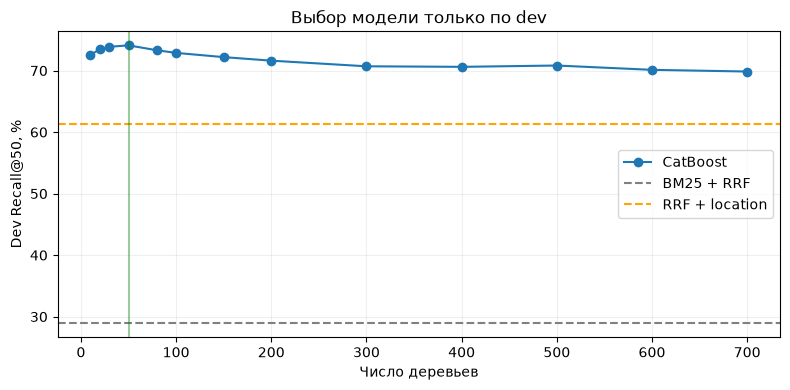

In [9]:
import matplotlib.pyplot as plt

selection = show_result("selected.json")
points = selection["candidates"]
fig, axis = plt.subplots(figsize=(8, 4))
axis.plot([row["trees"] for row in points],
          [100 * row["recall_50"] for row in points], marker="o", label="CatBoost")
axis.axhline(100 * selection["baseline_recall_50"], color="gray", linestyle="--", label="BM25 + RRF")
axis.axhline(100 * selection["geo_rrf"]["recall_50"], color="orange", linestyle="--", label="RRF + location")
axis.axvline(selection["trees"], color="green", alpha=0.4)
axis.set(xlabel="Число деревьев", ylabel="Dev Recall@50, %", title="Выбор модели только по dev")
axis.legend()
axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 8. Метрики dev

Baseline, простой учёт локации и обучаемая модель оцениваются на одинаковых запросах. Для CatBoost считаем парный bootstrap прироста к baseline.

In [10]:
execute_stage("dev_evaluate", "dev_metrics.json")

{'queries': 2000,
 'baseline_recall_50': 0.2895833333333333,
 'ranker_recall_50': 0.7410333333333333,
 'geo_rrf_recall_50': 0.612725,
 'selected_method': 'catboost_pairlogit',
 'selected_recall_50': 0.7410333333333333,
 'delta': 0.45145,
 'ranker_ci95': [0.7213981249999999, 0.75915],
 'delta_ci95': [0.428, 0.4750600000000001],
 'model_sha256': 'bdec464db6daa2cd293ad3a630563d91e03482587a6521a6e65aca8852e18035'}

## 9. Фиксация эксперимента

Сохраняем контрольные суммы модели, кода, данных для обучения и выбранных параметров. После этого изменения не должны направляться результатами holdout.

In [11]:
execute_stage("freeze", "frozen_experiment.json")

{'files': {'results/ranker.cbm': 'bdec464db6daa2cd293ad3a630563d91e03482587a6521a6e65aca8852e18035',
  'results/selected.json': 'a766e1ff61883cef3e2101bce9f5352636b86bf83f4b1948d211f4eaad4c3391',
  'results/training.json': '153a4c41125974fa9e9009e0743b1df6effdbb74ae9e42b8459b27b46db664d0',
  'results/split_audit.json': '81008a7d8337017973836a23d7a3c12b0531c85fdbde6bd01a15e4dc39655f1b',
  'results/input_check.json': '78e52da5ba0ca9f60363c219fb66bb7b8be6c915794eee63a835b54f8c75fe90',
  'results/leakage_audit.json': '3a42f14fd01d9c82a704186c0126664333d7431fc77eea15df3e85f82843a697',
  'avito_ranker/__init__.py': 'a8a3c48ab8dd96e3c3d91bafe57a08f9d44392fc31363122fb63dabe5f05b746',
  'avito_ranker/candidates.py': '2c50ba641b97ed84a835884810fc80f453f1c2adcc79d07b9115a9659d966973',
  'avito_ranker/config.py': 'af061f4952e75fd0bc0692842ab3e8ee99dc931391e129dd525384d7230cc0b7',
  'avito_ranker/dataset.py': '8327cc8403a1a98c33d4cd85081346c949dd65994770e5fd8ce6123b3e15e43d',
  'avito_ranker/featur

## 10. Закрытая часть: кандидаты

Первый расчёт качества на holdout происходит после фиксации. Поиск и признаки применяются без изменения настроек.

In [12]:
execute_stage("holdout_features", "holdout_candidates.json")

{'fold': 'holdout',
 'queries': 2000,
 'rows': 1875619,
 'features': ['title_score',
  'title_relative',
  'title_rr',
  'title_local_rr',
  'description_score',
  'description_relative',
  'description_rr',
  'description_local_rr',
  'params_score',
  'params_relative',
  'params_rr',
  'params_local_rr',
  'filter_score',
  'filter_relative',
  'rrf',
  'same_location',
  'same_category',
  'delivery',
  'query_words',
  'filter_words',
  'title_length',
  'title_coverage',
  'title_jaccard',
  'params_length',
  'params_coverage',
  'filter_coverage',
  'item_price',
  'item_rating',
  'item_rating_reviews_count',
  'item_is_phone_hidden',
  'item_is_message_forbidden'],
 'seconds': 172.62421720003476,
 'feature_file_sha256': 'fb73cbabbdb3578b36ef11f199e0280f5111dec8264722a37eaedf2ad7d1de10',
 'baseline_recall_50': 0.277625,
 'pool_recall': 0.8634166666666667,
 'queries_without_positive_in_pool': 268}

## 11. Итоговая локальная оценка

Для каждого запроса считаем пересечение топ-50 с известными положительными объявлениями, делим на число всех известных положительных и усредняем по запросам. Сюда входят и полные промахи поиска.

In [13]:
execute_stage("holdout_evaluate", "holdout_metrics.json")

{'queries': 2000,
 'baseline_recall_50': 0.277625,
 'ranker_recall_50': 0.7245,
 'geo_rrf_recall_50': 0.5869583333333332,
 'selected_method': 'catboost_pairlogit',
 'selected_recall_50': 0.7245,
 'delta': 0.446875,
 'ranker_ci95': [0.7033322916666667, 0.7427520833333333],
 'delta_ci95': [0.423746875, 0.46891875000000005],
 'model_sha256': 'bdec464db6daa2cd293ad3a630563d91e03482587a6521a6e65aca8852e18035'}

## 12. Корпус benchmark

Строим индексы только по 189 212 объявлениям benchmark. Параметры поиска и модель остаются зафиксированными.

In [14]:
execute_stage("benchmark_indices")

'Лог этапа: results/logs/benchmark_indices'

## 13. Кандидаты benchmark

Применяем тот же поиск и те же признаки к 2 452 запросам benchmark. Никаких тестовых положительных меток здесь нет.

In [15]:
execute_stage("benchmark_features", "benchmark_candidates.json")

{'fold': 'benchmark',
 'queries': 2452,
 'rows': 2092376,
 'features': ['title_score',
  'title_relative',
  'title_rr',
  'title_local_rr',
  'description_score',
  'description_relative',
  'description_rr',
  'description_local_rr',
  'params_score',
  'params_relative',
  'params_rr',
  'params_local_rr',
  'filter_score',
  'filter_relative',
  'rrf',
  'same_location',
  'same_category',
  'delivery',
  'query_words',
  'filter_words',
  'title_length',
  'title_coverage',
  'title_jaccard',
  'params_length',
  'params_coverage',
  'filter_coverage',
  'item_price',
  'item_rating',
  'item_rating_reviews_count',
  'item_is_phone_hidden',
  'item_is_message_forbidden'],
 'seconds': 64.4486981999944,
 'feature_file_sha256': '70b30b243258c4d7bd220d2c8214a8d8a8a3f1d0ff8ebf33a874870849b6d13d'}

## 14. Файл ответа

Выбираем 50 объявлений, возвращаем исходные `item_id` и записываем только `query_id,answer`. Проверяем покрытие запросов, формат ID, отсутствие повторов и принадлежность корпусу.

In [16]:
execute_stage("predict", "submission_check.json")

{'valid': True,
 'rows': 2452,
 'min_items': 50,
 'max_items': 50,
 'sha256': 'f4ffbb7029d6ad1bb53f97b88bceb76a0a7d2fe51d681a4d905a4c6d23e48cc5',
 'model_sha256': 'bdec464db6daa2cd293ad3a630563d91e03482587a6521a6e65aca8852e18035'}

## 15. Независимая проверка

Пересчитываем Recall по строковым ID сохранённых предсказаний и исходной разметки. Отдельно проверяем CSV и фиксируем версии библиотек.

In [17]:
execute_stage("check", "verification.json")

{'dev': {'queries': 2000, 'independent_recall_50': 0.7410333333333333},
 'holdout': {'queries': 2000, 'independent_recall_50': 0.7245},
 'submission': {'valid': True,
  'rows': 2452,
  'min_items': 50,
  'max_items': 50,
  'sha256': 'f4ffbb7029d6ad1bb53f97b88bceb76a0a7d2fe51d681a4d905a4c6d23e48cc5'},
 'environment': {'python': '3.12.10',
  'packages': {'numpy': '2.3.5',
   'scipy': '1.16.3',
   'polars': '1.40.1',
   'pyarrow': '24.0.0',
   'bm25s': '0.2.14',
   'snowballstemmer': '3.0.1',
   'catboost': '1.2.10'}}}

## Что отправлять

`answer.csv` в корне репозитория — предсказания для формы Авито. Последняя ячейка экспортирует его из `results/answer.csv`. Для проверки решения приложите этот notebook, папки с кодом, `ranking.toml`, зависимости, README и результаты эксперимента в соответствии с формой сдачи.

## Ограничения

Разметка содержит наблюдавшиеся положительные пары, а не все подходящие объявления. Неотмеченные кандидаты могут быть релевантными. Группировка не объединяет все синонимы. Локальный корпус больше benchmark, а распределение выбранных групп не обязано повторять тест. По этим причинам локальная метрика не обещает такой же результат на закрытом тесте.

## Источники

[BM25S](https://github.com/xhluca/bm25s), [Snowball](https://snowballstem.org/algorithms/russian/stemmer.html), [RRF](https://cormack.uwaterloo.ca/cormacksigir09-rrf.pdf), [CatBoostRanker](https://catboost.ai/docs/en/concepts/python-reference_catboostranker).

## 16. Экспорт ответа для сдачи

Предсказания уже проверены на этапе `predict`. Сохраняем точную копию CSV
в корне репозитория, чтобы файл для отправки находился рядом с notebook.

In [18]:
import shutil

answer_path = config_path.parent / "answer.csv"
shutil.copyfile(config["results_dir"] / "answer.csv", answer_path)
assert answer_path.read_bytes() == (config["results_dir"] / "answer.csv").read_bytes()
{"answer": answer_path.name, "rows": show_result("submission_check.json")["rows"]}

{'answer': 'answer.csv', 'rows': 2452}